# Point clouds

`Scene3D.point_cloud` renders scattered points (LiDAR, observations, raster cells) as depth-cued markers with optional per-point colour and **eye-dome lighting** (the shading that makes dense clouds legible). Input is either an `(N, 3)` / `(N, 2)` NumPy table or a GeoDataFrame of `Point`s (duck-typed — no geopandas import).

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

from pyramids.dataset import Dataset
from digitalearth.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'

def show(scene, title=''):
    """Screenshot a scene off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]          # exclude the bottom colour-bar strip
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} of the scene differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


2026-06-11 21:05:20 | INFO | pyramids.base.config | Logging is configured.


## A DEM sampled to an xyz cloud

The DEM's x/y are degrees but elevation is metres, so we scale z into degree-equivalent units (the same convention `terrain` applies internally) — otherwise the cloud collapses to a vertical line.

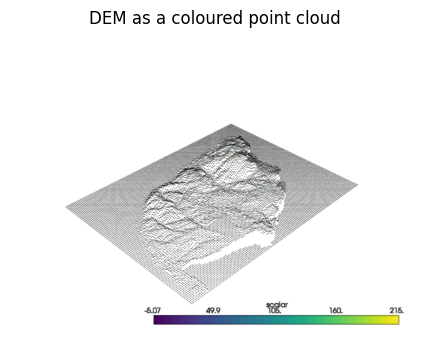

In [2]:
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
arr = dem.read_array()[::4, ::4]
xx, yy = np.meshgrid(dem.x[::4], dem.y[::4])
finite = np.isfinite(arr.ravel())
elevation = arr.ravel()[finite]
z = elevation / 111_320.0 * 8.0                          # metres -> degree-equivalent, 8x exaggeration
pts = np.column_stack([xx.ravel()[finite], yy.ravel()[finite], z])
scene = Scene3D(off_screen=True)
scene.point_cloud(pts, values=elevation, point_size=4.0, cmap='viridis')
show(scene, 'DEM as a coloured point cloud')
scene.close()

## Eye-dome lighting on vs off

Eye-dome lighting (default on) darkens depth discontinuities so structure pops; without it a dense cloud flattens into a blob.

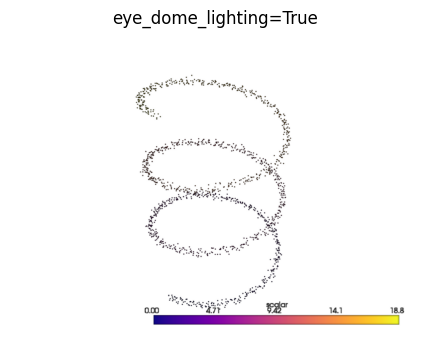

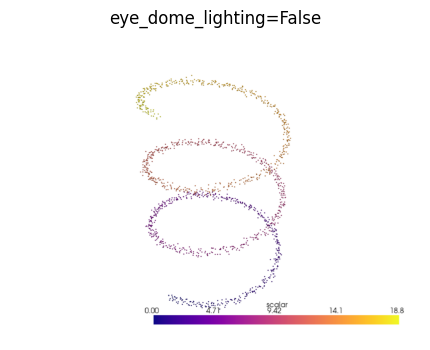

In [3]:
rng = np.random.default_rng(0)
t = np.linspace(0, 6 * np.pi, 1500)
helix = np.column_stack([np.cos(t), np.sin(t), t / 6]) + rng.normal(0, 0.03, (t.size, 3))
for edl in (True, False):
    scene = Scene3D(off_screen=True)
    scene.point_cloud(helix, values=t, point_size=6.0, eye_dome_lighting=edl, cmap='plasma')
    show(scene, f'eye_dome_lighting={edl}')
    scene.close()

## From a GeoDataFrame of observations

Pass a points GeoDataFrame and colour by an attribute column with `value_column`. Here: Rhine gauges coloured by discharge (lifted to z by the same value for a simple 3-D lollipop look).

C:\python-environments\pixi\envs\digitalearth-9757176958511839721\envs\viz3d\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 5 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


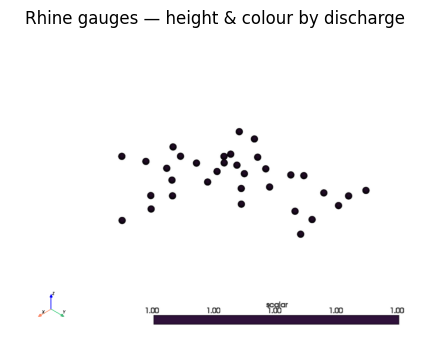

In [4]:
import geopandas as gpd
gauges = gpd.read_file(str(DATA / 'rhine_gauges.geojson')).dropna(subset=['discharge'])
gauges = gauges.copy()
gauges['geometry'] = gpd.points_from_xy(
    gauges.geometry.x, gauges.geometry.y, gauges['discharge'] / gauges['discharge'].max() * 3.0)
scene = Scene3D(off_screen=True)
scene.point_cloud(gauges, value_column='discharge', point_size=40.0, cmap='turbo')
scene.plotter.add_axes()
show(scene, 'Rhine gauges — height & colour by discharge')
scene.close()